# Исследовательский анализ сервиса Яндекс Афиша и проверка гипотез

## Цель и задачи

**Цель:**

Проанализировать динамику пользовательской активности и изменения в продажах билетов с помощью сервиса Яндекс Афиша при переходе от летнего к осеннему периоду 2024 года. Изучить влияние сезонности на продажи и ценовую политику в разрезе типов мероприятий,  устройств и категорий мероприятий по возрастному рейтингу.

**Задачи:**

1. Загрузить данные и провести их предобработку;
2. Провести исследовательский анализ данных включающий в себя:
- Изучение распределения заказов по сегментам и их сезонные изменения;
- Анализ осенней активности пользователей по дням недели;
- Анализ популярных событий и партнёров.
3. Провести статистический анализ данных;
4. Сформулировать выводы и рекомендации по проведённому анализу.

## Описание данных

Для работы будут использованы данные датасетов `final_tickets_orders_df.csv`, `final_tickets_events_df.csv` и `final_tickets_tenge_df.csv`.

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных: 
- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа (московское время);
- `created_ts_msk` — дата и время создания заказа (московское время);
- `event_id` — идентификатор мероприятия;
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты, например rub для российских рублей;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных;
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:

- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия;
- `event_type_description` — описание типа мероприятия;
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее;
- `organizers` — организаторы мероприятия;
- `region_name` — название региона;
- `city_name` — название города;
- `venue_id` — уникальный идентификатор площадки;
- `venue_name` — название площадки;
- `venue_address` — адрес площадки.

Третий датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге:

- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt).

### Содержание

1. [Загрузка и знакомство с данными](#1-bullet)
2. [Проверка ошибок в данных и их предобработка](#2-bullet)

    2.1 [Проверка уникальности категориальных значений](#2.1-bullet)

    2.2 [Распределение и наличие выбросов для количественных значений](#2.2-bullet) 

    2.3 [Явные и неявные дубликаты в данных](#2.3-bullet)
    
    2.4 [Корректировка типов данных](#2.4-bullet)
    
    2.5 [Создание новых столбцов](#2.5-bullet)

   
3. [Исследовательский анализ данных](#3-bullet)

    3.1 [Анализ распределения заказов по сегментам и их сезонные изменения](#3.1-bullet)

    3.2 [Осенняя активность пользователей](#3.2-bullet)

    3.3 [Популярные события и партнёры](#3.3-bullet)

   
4. [Статистический анализ данных](#4-bullet)

4.1 [Подготовка выборок для теста](#4.1-bullet)

4.2 [Сравнение размеров групп и их статистик](#4.2-bullet)

4.3 [Проведение теста](#4.3-bullet)


5. [Общий вывод и рекомендации](#5-bullet)

<a class="anchor" id="1-bullet" ></a>
## 1. Загрузка и знакомство с данными

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Импортируем инструменты
from statsmodels.stats.power import TTestIndPower
from scipy.stats import ttest_ind

In [2]:
# Загружаем датасеты
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tenge_tickets = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
display(df_orders.info())
display(df_orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
display(df_events.info())
display(df_events.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
display(df_tenge_tickets.info())
display(df_tenge_tickets.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Датасет `df_orders` содержит 14 столбцов и 290849 строк. Имеются пропуски в столбце `days_since_prev`. Это объясняется тем, что предыдущей покупки не было совершено, т.к. столбец содержит количество дней с предыдущей покупки для каждого пользователя. Это значит, что у примерно 22 тысяч заказов это первая покупка пользователя. Такие пропуски не требуют обработки. Сам столбуц приведем к типу `Int16` т.к. в нем содержаться целые числа.

Столбцы `created_dt_msk` и `created_ts_msk` типа `object`. Для данных о дате и времени следует использовать тип `datetime64`, который облегчит выполнение временных вычислений и упростит анализ временных периодов.

Датасет `df_events` содержит 11 столбцов и 22427 строк, пропусков нет и типы данных корректны.

Датасет `df_tenge_tickets` содержит 4 столбца и 357 строк. Отсутствуют первые 9 дней января. Не содержит пропуски, тип данных в столбце `data` следует привести к `datetime64`.

<a class="anchor" id="2-bullet" ></a>
## 2. Проверка ошибок в данных и их предобработка

<a class="anchor" id="2.1-bullet" ></a>
### 2.1 Проверка уникальности категориальных значений

In [6]:
# Проверим категориальные значения
print(f"Типы устройств: {df_orders['device_type_canonical'].unique()}")
print(f"\nНазвания билетных операторов: {sorted(df_orders['service_name'].unique())}")
print(f"\nОписание типов мероприятий: {sorted(df_events['event_type_description'].unique())}")
print(f"\nОсновные типы мероприятий: {df_events['event_type_main'].unique()}")
print(f"\nЗначения возрастного рейтинга: {sorted(df_orders['age_limit'].unique())}")

Типы устройств: ['mobile' 'desktop']

Названия билетных операторов: ['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']

Описание типов мероприятий: ['балет', 'выставка', 'концерт', 'кукольный спектакль', 'музыкальный спектакль', 'мюзикл', 'опера', 'оперетта', 'подарок', 'рок-мюзикл', 'снегурочка', 'событие', 'спектакль', 'спорт', 'спортивное мероприятие', 'фестиваль', 'цирковое шоу', 'шоу', 'экскурсия', 'ёлка']

Основные типы мероприятий: ['театр' 'концерты' 'ёлки' 'другое' 'стендап' 'выставки' 'спо

Категориальные значения являются уникальными.

<a class="anchor" id="2.2-bullet" ></a>
### 2.2 Распределение и наличие выбросов для количественных значений 

In [7]:
# Разделим данные на рубли и тенге
df_rub = df_orders[df_orders['currency_code'] == 'rub']
df_kzt = df_orders[df_orders['currency_code'] == 'kzt']

# Смотрим статистику по рублям
print("Статистические показатели столбцов в рублях:")
display(df_rub[['revenue', 'tickets_count']].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Смотрим статистику по тенге
print("Статистические показатели столбцов в тенге:")
display(df_kzt[['revenue', 'tickets_count']].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]))

Статистические показатели столбцов в рублях:


,revenue,tickets_count
count,285780.000000,285780.000000
mean,547.568333,2.754077
std,871.524559,1.171419
min,-90.760000,1.000000
1%,0.000000,1.000000
25%,113.827500,2.000000
50%,346.100000,3.000000
75%,791.700000,4.000000
95%,1606.500000,5.000000
99%,2569.594200,6.000000


Статистические показатели столбцов в тенге:


,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
1%,90.270000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
95%,13784.260000,5.000000
99%,17617.240000,6.000000


Статистические показатели в рублях имеют выбросы, отберем значения по 99-му процентилю. Также минимальное значение -90.7, означает возврат.

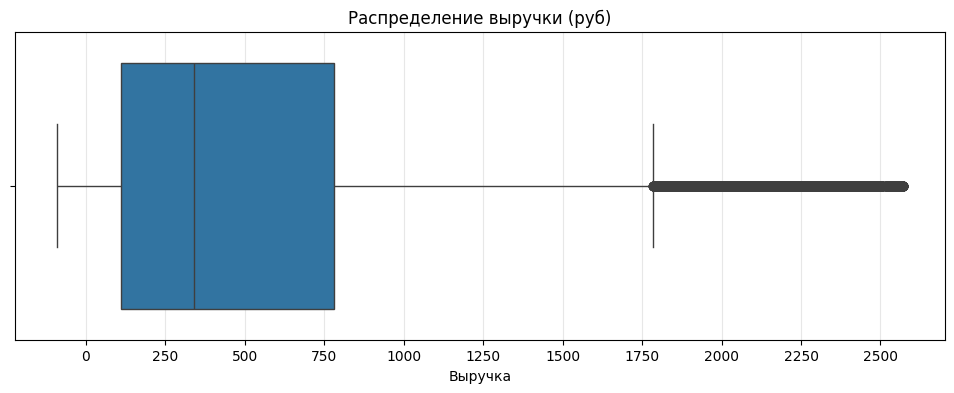

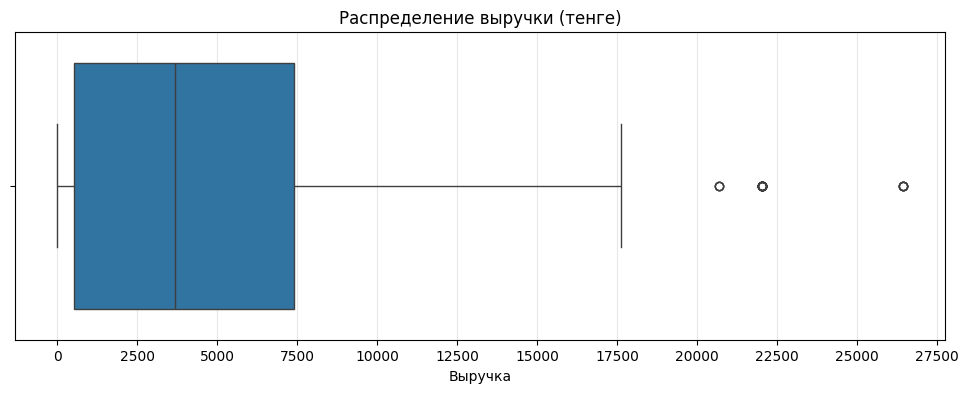

In [8]:
# Построим диаграмму размаха для выручки в рублях
plt.figure(figsize=(12, 4))

# Для рублей отберем значения по 99-му процентилю 
df_rub = df_rub[df_rub['revenue'] <= df_rub['revenue'].quantile(0.99)]

sns.boxplot(x = df_rub['revenue'])

plt.title('Распределение выручки (руб)')
plt.xlabel('Выручка')
plt.xticks(range(0, 2601, 250))
plt.grid(axis='x', alpha=0.3)

plt.show()

# Построим диаграмму размаха для выручки в тенге
plt.figure(figsize=(12, 4))

sns.boxplot(x = df_kzt['revenue'])

plt.title('Распределение выручки (тенге)')
plt.xlabel('Выручка')
plt.xticks(range(0, 28001, 2500))
plt.grid(axis='x', alpha=0.3)

plt.show()

In [9]:
# Оставим в данных значения по 1-му и 99-му процентилю для рублей, а также отбросим отрицательную и нулевую выручку
all_str = len(df_orders)
print(f'Количество строк до очистки: {all_str}')

limit_rub_max = df_orders[df_orders['currency_code'] == 'rub']['revenue'].quantile(0.99)
limit_rub_min = df_orders[df_orders['currency_code'] == 'rub']['revenue'].quantile(0.01)

df_orders = df_orders[
    ((df_orders['currency_code'] == 'rub') &
    (df_orders['revenue'] <= limit_rub_max) & 
    (df_orders['revenue'] >= limit_rub_min) & 
    (df_orders['revenue'] > 0)) |
    ((df_orders['currency_code'] == 'kzt') & (df_orders['revenue'] > 0))
]

clean_orders = len(df_orders)

print(f'Количество строк после очистки: {clean_orders}')
print(f'Удалено строк: {all_str-clean_orders}')

Количество строк до очистки: 290849
Количество строк после очистки: 281873
Удалено строк: 8976


На обеих диаграммах размаха правоасимметричное распределение.

Отобрав значения по 99-му процентилю для рублей видно, что половина значений лежит в диапазоне от ~100 до ~740 руб., медиана находится в районе ~ 330-340 руб.

Для тенге 50% значений находятся в диапазоне от ~500 до ~7400, медиана находится в районе ~3700 тенге.

<a class="anchor" id="2.3-bullet" ></a>
### 2.3 Явные и неявные дубликаты в данных

In [10]:
# Проверим на наличие явных дубликатов
print(f'Явных дубликатов в датасете df_orders: {df_orders.duplicated().sum()}')

# Составляем список столбцов без учета order_id
check_cols = ['user_id', 'event_id', 'created_ts_msk', 'revenue', 'tickets_count', 'service_name', 'device_type_canonical']

# Ищем дубликаты по этим признакам
implicit_dups = df_orders.duplicated(subset = check_cols, keep = False)
print(f'Дубликатов по набору параметров заказа, не включая order_id: {implicit_dups.sum()}')

Явных дубликатов в датасете df_orders: 0
Дубликатов по набору параметров заказа, не включая order_id: 73


In [11]:
# Выведем первые 10 строк таких дубликатов
all_dups = df_orders[df_orders.duplicated(subset = check_cols, keep = False)]
display(all_dups.sort_values(by=['user_id', 'created_ts_msk']).head(10))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,11.0
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,0.0
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,32.0
53717,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
68214,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,1008.14,7.0
68215,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,1008.14,0.0


In [12]:
all_str = len(df_orders)
print(f'Количество строк до очистки: {all_str}')

# Удаляем эти дубликаты, оставляя первое вхождение
df_orders = df_orders.drop_duplicates(subset=check_cols, keep='first').reset_index(drop=True)

clean_df = len(df_orders)
print(f'Количество строк после очистки: {clean_df}')
print(f'Удалено строк: {all_str-clean_df}')
display(df_orders)

Количество строк до очистки: 281873
Количество строк после очистки: 281835
Удалено строк: 38


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281830,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6,rub,mobile,965.57,Весь в билетах,4,9655.73,0.0
281831,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6,rub,mobile,1448.36,Весь в билетах,6,14483.60,0.0
281832,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16,rub,desktop,178.95,Прачечная,2,4473.74,3.0
281833,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,Билеты без проблем,2,6615.34,NaN


Было найдено 73 дубликатов заказов по полям `user_id`, `event_id`, `created_ts_msk`, `revenue`, `tickets_count`, `service_name`, `device_type_canonical`. Это значит, что при разных `order_id` было осуществлено более одного заказа с идентичными данными пользователя, количеством билетов, выручкой и временем (вплоть до секунд).

Такое небольшое количество может указывать на единичные технические сбои: например, повторное нажатие кнопки оплаты из-за проблем с интернетом. Дубликаты было решено удалить, оставив только первые записи. Таким образом было удалено 38 строк.

<a class="anchor" id="2.4-bullet" ></a>
### 2.4 Корректировка типов данных

In [13]:
# Приводим столбцы с датой к нужному типу
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk']).dt.normalize()
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])
df_tenge_tickets['data'] = pd.to_datetime(df_tenge_tickets['data']).dt.normalize()

display(df_orders['created_dt_msk'].head())
display(df_orders['created_ts_msk'].head())
display(df_tenge_tickets['data'].head()) 

0   2024-08-20
1   2024-07-23
2   2024-10-06
3   2024-07-13
4   2024-10-04
Name: created_dt_msk, dtype: datetime64[ns]

0   2024-08-20 16:08:03
1   2024-07-23 18:36:24
2   2024-10-06 13:56:02
3   2024-07-13 19:40:48
4   2024-10-04 22:33:15
Name: created_ts_msk, dtype: datetime64[ns]

0   2024-01-10
1   2024-01-11
2   2024-01-12
3   2024-01-13
4   2024-01-14
Name: data, dtype: datetime64[ns]

In [14]:
# Объединим датафреймы df_orders и df_events
df_afisha = df_orders.merge(df_events, on = 'event_id', how = 'inner')

# Приведем столбец к типу Int и снизим размерность
df_afisha['days_since_prev'] = df_afisha['days_since_prev'].astype('Int16')

# Снижаем размерность количественных данных
for col in ['order_id', 'event_id', 'city_id', 'venue_id', 'tickets_count']:
    df_afisha[col] = pd.to_numeric(df_afisha[col], downcast = 'integer')
    
for col in ['revenue', 'total', 'city_id', 'venue_id']:
    df_afisha[col] = pd.to_numeric(df_afisha[col], downcast = 'float')

In [15]:
# Отредактируем столбец age_limit, добавив '+' и присвоим ему тип 'category'
df_afisha['age_limit'] = df_afisha['age_limit'].astype(str) + '+'

age_order = ['0+', '6+', '12+', '16+', '18+']

df_afisha['age_limit'] = pd.Categorical(
    df_afisha['age_limit'], 
    categories=age_order, 
    ordered=True
)

<a class="anchor" id="2.5-bullet" ></a>
### 2.5 Создание новых столбцов

In [16]:
# Поскольку в данных о курсе нет первых дней января, посмотрим начальную и конечную даты в основном датасете
print(f"Самая ранняя дата в данных: {df_afisha['created_dt_msk'].min()}")
print(f"Самая поздняя дата в данных: {df_afisha['created_dt_msk'].max()}")

Самая ранняя дата в данных: 2024-06-01 00:00:00
Самая поздняя дата в данных: 2024-10-31 00:00:00


In [17]:
# Создадим новые столбцы
# Приведем выручку с заказа к единой валюте - rub, с помощью датасета df_tenge_tickets
df_afisha = df_afisha.merge(df_tenge_tickets[['data','curs']], left_on='created_dt_msk', right_on='data', how='left')

df_afisha['revenue_rub'] = np.where(
    df_afisha['currency_code'] == 'rub',
    df_afisha['revenue'],
    (df_afisha['revenue'] / 100) * df_afisha['curs']
)

# Выручка с продажи одного билета на мероприятие
df_afisha['one_ticket_revenue_rub'] = df_afisha['revenue_rub'] / df_afisha['tickets_count']

# Месяц оформления заказа
df_afisha['month'] = df_afisha['created_dt_msk'].dt.month

# Информация о сезонности
season_dict = {
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4:'весна', 5:'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}
df_afisha['season'] = df_afisha['month'].map(season_dict)

# Удалим столбцы с датой и курсом из df_tenge_tickets
df_afisha = df_afisha.drop(columns=['data', 'curs'])

# Снизим размерность в новых столбцах
df_afisha['month'] = pd.to_numeric(df_afisha['month'], downcast = 'integer')
for col in ['revenue_rub', 'one_ticket_revenue_rub']:
    df_afisha[col] = pd.to_numeric(df_afisha[col], downcast = 'float')

display(df_afisha.info())
display(df_afisha)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281808 entries, 0 to 281807
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281808 non-null  int32         
 1   user_id                 281808 non-null  object        
 2   created_dt_msk          281808 non-null  datetime64[ns]
 3   created_ts_msk          281808 non-null  datetime64[ns]
 4   event_id                281808 non-null  int32         
 5   cinema_circuit          281808 non-null  object        
 6   age_limit               281808 non-null  category      
 7   currency_code           281808 non-null  object        
 8   device_type_canonical   281808 non-null  object        
 9   revenue                 281808 non-null  float64       
 10  service_name            281808 non-null  object        
 11  tickets_count           281808 non-null  int8          
 12  total                   281808

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16+,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213.0,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.939941,380.484985,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0+,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213.0,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.450012,144.725006,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0+,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.569946,314.642487,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0+,rub,mobile,8.49,...,Североярская область,Озёрск,2.0,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.490000,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18+,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.410034,463.470001,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281803,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6+,rub,mobile,965.57,...,Каменевский регион,Глиногорск,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",965.570007,241.392502,10,осень
281804,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6+,rub,mobile,1448.36,...,Каменевский регион,Глиногорск,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",1448.359985,241.393326,10,осень
281805,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16+,rub,desktop,178.95,...,Каменевский регион,Глиногорск,213.0,3470,"Клуб киноманов ""Верность"" Лтд","пр. Титова, д. 5 стр. 68",178.949997,89.474998,10,осень
281806,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18+,rub,desktop,661.53,...,Широковская область,Ягодиновка,239.0,2449,"Гильдия художников ""Флит"" Инк","пр. Макарова, д. 4",661.530029,330.765015,9,осень


В результате предобработки данных были получены такие результаты:

1. Для данных в рублях были отобраны значения по 1-му и 99-му процентилю, а также отброшены данные с выручкой < 0. Таким образом было удалено 8976 строк;
2. Было удалено 38 неявных дубликатов;
3. Скорректированы типы данных в столбцах с датой и временем;
4. Данные были объединены в единый датафрейм `df_afisha`;
5. Снижена размерность количественных данных;
6. Отредактирован столбец `age_limit`. Добавлен '+' и присвоен тип `category`;
7. В объединенном датафрейме созданы новые столбцы:
- `revenue_rub` — выручка с заказа, приведенная к единой валюте — российскому рублю. Для этого использовался датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю `final_tickets_tenge_df.csv` за 2024 год;
- `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие;
- `month` — месяц оформления заказа;
- `season` — информация о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

<a class="anchor" id="3-bullet" ></a>
## 3. Исследовательский анализ данных

<a class="anchor" id="3.1-bullet" ></a>
### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

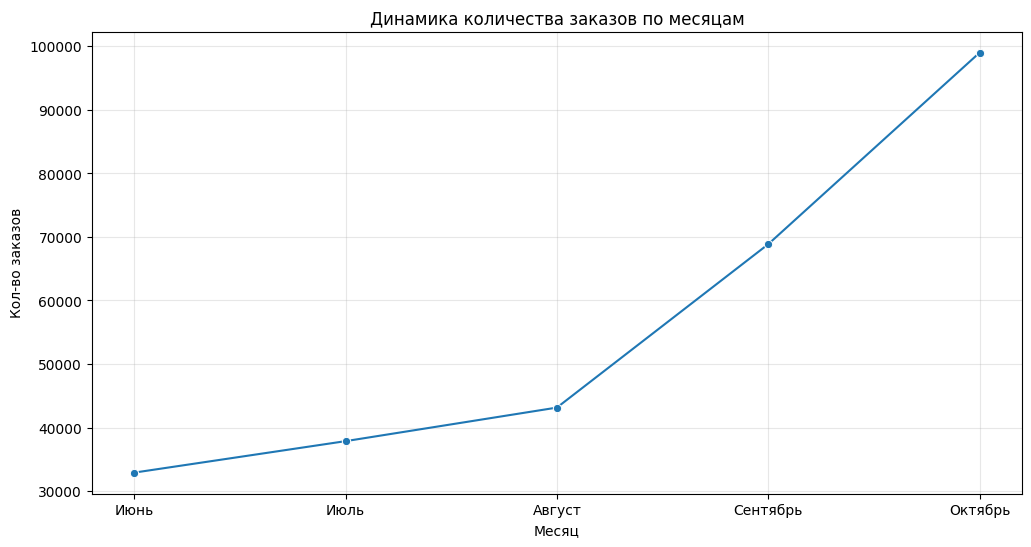

In [18]:
df_plot = df_afisha.groupby('month')['order_id'].count().reset_index()
month_names = {
    6: 'Июнь', 7: 'Июль', 8: 'Август', 
    9: 'Сентябрь', 10: 'Октябрь'
}
ticks = sorted(df_plot['month'].unique())
labels = [month_names.get(m, m) for m in ticks]

plt.figure(figsize=(12,6))

sns.lineplot(
    data = df_plot,
    x = 'month',
    y = 'order_id',
    marker = 'o'
)

plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во заказов')
plt.xticks(df_plot['month'].unique())
plt.grid(True, alpha=0.3)
plt.xticks(ticks, labels)

plt.show()

На графике видно, что количество заказов растет с каждым месяцем.

<a class='anchor' id="link1"></a>

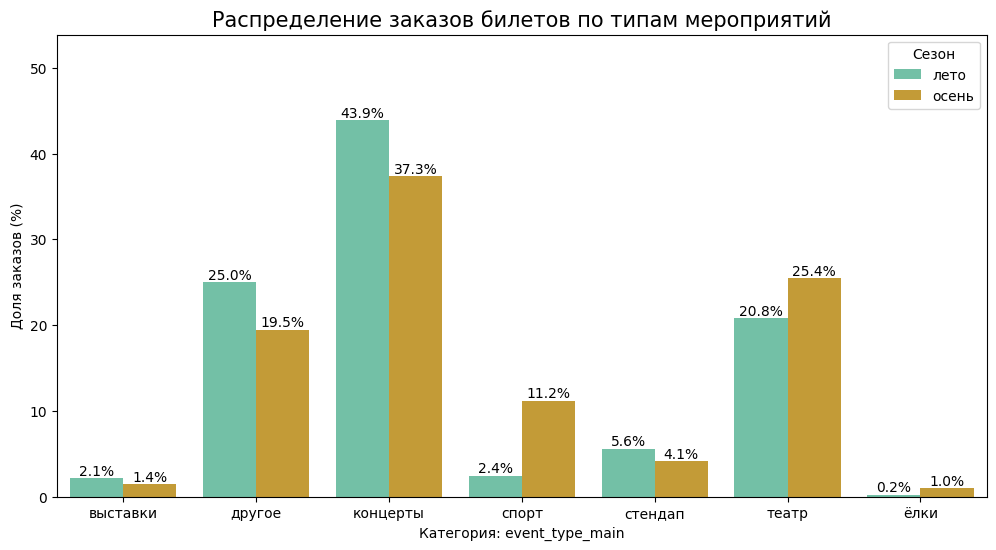

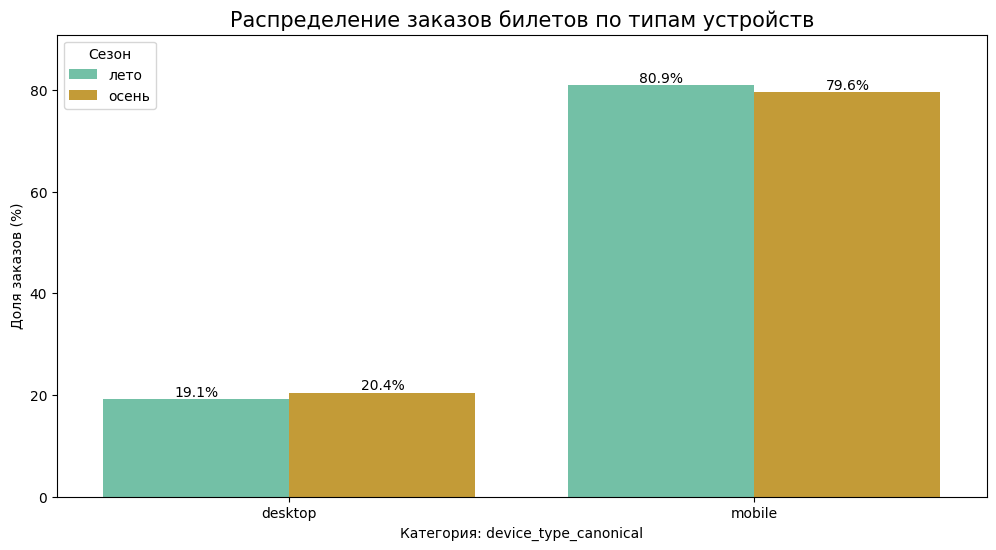

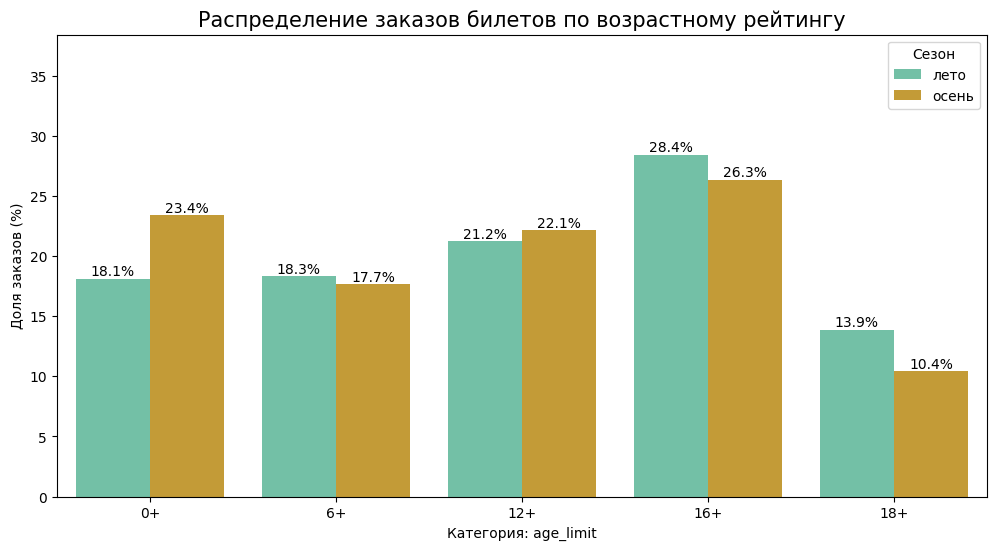

In [19]:
# Создадим функцию, строющую график кол-ва заказов по сезону и категории
def barplot_season_cat_orders(df, category, title):
    # Группировка по сезону и категории
    counts = df.groupby(['season', category], observed=False)['order_id'].count().reset_index()
    # Общее кол-во заказов за сезон
    total_orders = df.groupby('season', observed=False)['order_id'].count().reset_index()
    df_result = counts.merge(total_orders, on='season', suffixes=('', '_total'))
    df_result['share'] = (df_result['order_id'] / df_result['order_id_total'] * 100).round(2)
    
    # Строим столбчатую диаграмму
    plt.figure(figsize=(12, 6))
    my_palette = {'лето': '#66CDAA', 'осень': '#DAA520'}
    ax = sns.barplot(
        data = df_result, 
        x = category, 
        y = 'share', 
        hue = 'season', 
        palette = my_palette
    )
    for p in ax.patches:
        height = p.get_height()
        if height > 0.1:
            ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10)
    
    plt.title(title, fontsize=15)
    plt.ylabel('Доля заказов (%)')
    plt.xlabel(f'Категория: {category}')
    plt.legend(title='Сезон')
    plt.ylim(0, df_result['share'].max() + 10)
    plt.grid('')
    
    plt.show()

# Вызываем функцию для каждого разреза
barplot_season_cat_orders(df_afisha, 'event_type_main', 'Распределение заказов билетов по типам мероприятий')
barplot_season_cat_orders(df_afisha, 'device_type_canonical', 'Распределение заказов билетов по типам устройств')
barplot_season_cat_orders(df_afisha, 'age_limit', 'Распределение заказов билетов по возрастному рейтингу')

In [20]:
other_type = df_afisha[df_afisha['event_type_main'] == 'другое']
print(f"В тип мероприятия \'другое\' входит: {other_type['event_type_description'].unique()}")

В тип мероприятия 'другое' входит: ['цирковое шоу' 'выставка' 'событие' 'шоу' 'музыкальный спектакль'
 'кукольный спектакль' 'оперетта' 'снегурочка' 'рок-мюзикл' 'экскурсия'
 'подарок']


**Промежуточные выводы по графикам:**

1. **Распределение заказов билетов по типам мероприятий**

Летом популярностью пользуются концерты (43.9%) от всех летних продаж и категория 'другое' (25%) в которую входят выставки, спектакли, экскурсии, шоу.
Осенью заметно выросла доля театров (с 20.8% до 25.4%) и спортивных событий (с 2.4% до 11.2%). Доля концертов осенью снизилась (с 43.9% до 37.3%).

2. **Распределение заказов билетов по типам устройств**

На графике не видно заметных изменений. Мобильные устройства являются доминирующим типом (около 80%), доля стационарных устройств (около 20%).

3. **Распределение заказов билетов по возрастному рейтингу**

Осенью выросла доля категории '0+' (с 18.1% до 23.4%). Доля категорий (16+ и 18+) осенью, наоборот, сократилась.

In [21]:
# Строим таблицу со средней выручкой за билет по типу мероприятния летом и осенью
pivot_revenue = df_afisha.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean()\
        .unstack(level=0) \
        .rename_axis(None, axis=1) \
        .reset_index()

pivot_revenue['diff'] = (
    (pivot_revenue['осень'] - pivot_revenue['лето']) / pivot_revenue['лето'] * 100
).round(2)

display(pivot_revenue)

,event_type_main,лето,осень,diff
0,выставки,86.744476,91.905090,5.950000
1,другое,88.021278,77.421379,-12.040000
2,концерты,309.795746,268.146637,-13.440000
3,спорт,55.247120,50.245480,-9.050000
4,стендап,218.518097,231.124985,5.770000
5,театр,216.340149,176.084229,-18.610001
6,ёлки,271.436188,229.585587,-15.420000


<a class='anchor' id="link2"></a>

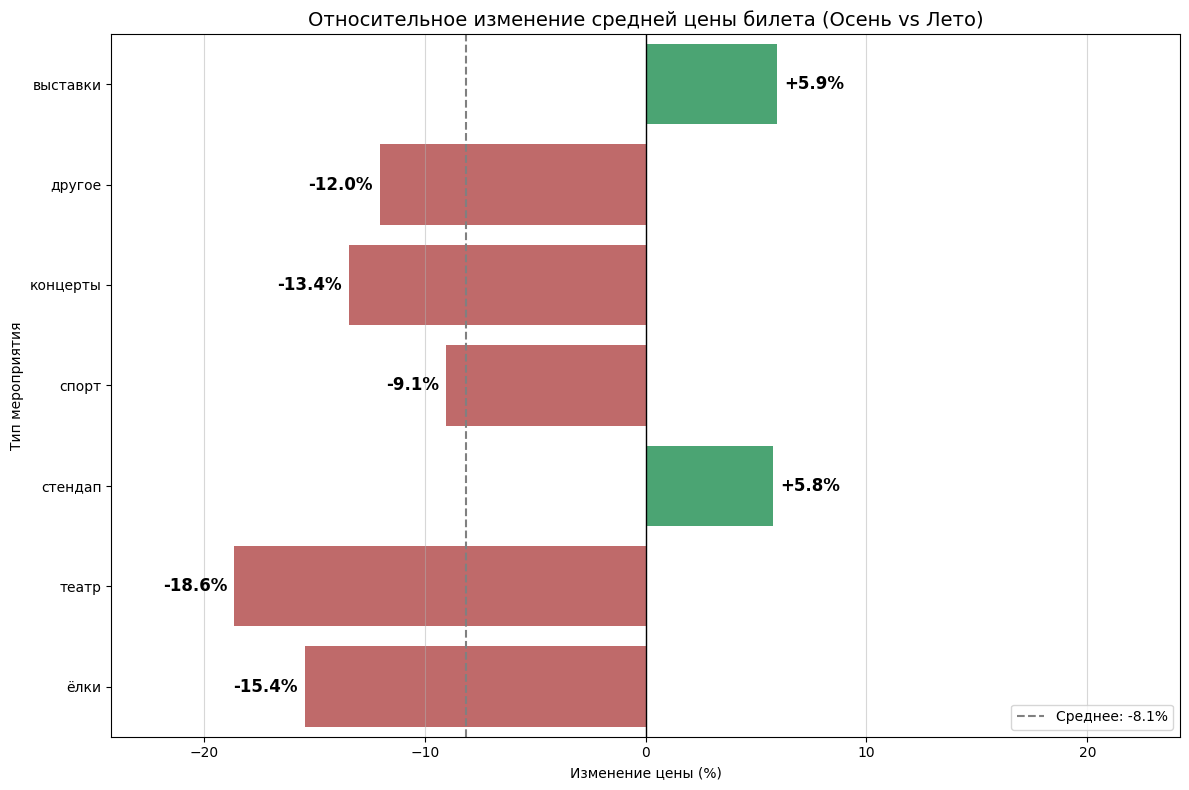

In [22]:
# Отобразим результаты на графике
plt.figure(figsize=(12, 8))

colors = ['#CD5C5C' if x < 0 else '#3CB371' for x in pivot_revenue['diff']]
min_diff = pivot_revenue['diff'].min()
max_diff = pivot_revenue['diff'].max()
limit = max(abs(min_diff), abs(max_diff)) * 1.3 
avg_diff = pivot_revenue['diff'].mean()

ax = sns.barplot(
    data = pivot_revenue,
    x = 'diff',
    y = 'event_type_main',
    palette = colors,
    hue = 'event_type_main',
    legend = False
)
    
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:+.1f}%', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left' if width > 0 else 'right', 
                va='center', 
                xytext=(5 if width > 0 else -5, 0), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.axvline(0, color='black', linewidth=1)
plt.axvline(avg_diff, color='gray', linestyle='--', linewidth=1.5, label=f'Среднее: {avg_diff:+.1f}%')
plt.title('Относительное изменение средней цены билета (Осень vs Лето)', fontsize=14)
plt.xlabel('Изменение цены (%)')
plt.ylabel('Тип мероприятия')
plt.grid(axis='x', linestyle='-', alpha=0.5)
plt.xlim(-limit, limit) 
plt.legend(loc='lower right')

plt.tight_layout()

plt.show()

График показал, что у большинства типов мероприятий средняя цена билета в осенний период относительно летнего снижается. Исключениями являются мероприятия типа выставки и стендап, где цена за билет возрастает почти на 6%.

Среднее снижение цены билета осенью составляет -8.1%.

**Выводы:**

1. **Динамика количества заказов.** 

Количество заказов стабильно растет. Пик активности приходится на осенние месяцы: октябрь — около 100 000 заказов, сентябрь —около 70 000 заказов. Интерес пользователей к покупке билетов значительно возрастает осенью, по сравнению с летом. Возможна связь с окончанием сезона отпусков / каникул и возвращением людей в город и переходом к проведению досуга в формате 'вечерних' или 'выходных' мероприятий.


2. **Распределение заказов билетов.** 
- *Тип мероприятия.* Осенью видно изменение в предпочтительных типах мероприятий для пользователей. Возрастает интерес к театрам и спортивным событиям, в то время как доля концертов и различных шоу, выставок, спектаклей, экскурсий из категории 'другое' снижается. Это может свидетельствовать о переходе аудитории на закрытые площадки.
- *Тип устройства.* Распределение стабильно и не зависит от сезона. Около 80% трафика приходится на мобильные устройства и около 20% на стационарные. Это подтверждает, что смартфон остается основным инструментом пользователя для планирования досуга.
- *Возрастной рейтинг.* Категории 6+ и 12+ не претерпели заметных изменений, связанных с сезонностью. Фиксируется рост доли заказов билетов для категории 0+ и снижение доли для категорий 16+ и 18+. Осенью интерес пользователей смещается на мероприятия для маленьких детей.

3. **Изменение выручки с продажи одного билета.**

Несмотря на общий рост количества заказов, средняя стоимость одного билета в большинстве категорий снизилась. Исключением стали выставки и стендап. Они выбиваются из общего тренда и в этих категориях присутствует рост выручки с одного билета. Таким образом осенняя выручка достигается не ценой одного билета, а количеством проданных билетов.

<a class="anchor" id="3.2-bullet" ></a>
### 3.2 Осенняя активность пользователей

In [23]:
# Создадим датасет, в который войдут только осенние данные
df_autumn = df_afisha[df_afisha['season'] == 'осень'].reset_index(drop = True)
display(df_autumn)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0+,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.569946,314.642487,10,осень
1,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18+,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.410034,463.470001,10,осень
2,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12+,rub,mobile,902.74,...,Лугоградская область,Кристалевск,193.0,930,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",902.739990,300.913330,10,осень
3,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12+,rub,mobile,47.78,...,Поленовский край,Дальнозолотск,18.0,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",47.779999,47.779999,9,осень
4,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12+,rub,mobile,74.84,...,Поленовский край,Дальнозолотск,18.0,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",74.839996,37.419998,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167839,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6+,rub,mobile,965.57,...,Каменевский регион,Глиногорск,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",965.570007,241.392502,10,осень
167840,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6+,rub,mobile,1448.36,...,Каменевский регион,Глиногорск,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",1448.359985,241.393326,10,осень
167841,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16+,rub,desktop,178.95,...,Каменевский регион,Глиногорск,213.0,3470,"Клуб киноманов ""Верность"" Лтд","пр. Титова, д. 5 стр. 68",178.949997,89.474998,10,осень
167842,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18+,rub,desktop,661.53,...,Широковская область,Ягодиновка,239.0,2449,"Гильдия художников ""Флит"" Инк","пр. Макарова, д. 4",661.530029,330.765015,9,осень


In [24]:
# Создадим таблицу с дневной статистикой
daily_stats = df_autumn.groupby('created_dt_msk').agg(
        orders_count = ('order_id', 'count'),
        dau = ('user_id', 'nunique'),
        avg_ticket_price = ('one_ticket_revenue_rub', 'mean')
)
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

display(daily_stats)

,orders_count,dau,avg_ticket_price,orders_per_user
created_dt_msk,,,,
2024-09-01,1314,555,202.149063,2.367568
2024-09-02,1370,571,190.847824,2.399299
2024-09-03,5088,776,80.492607,6.556701
2024-09-04,1757,683,179.304230,2.572474
2024-09-05,1940,738,189.902313,2.628726
...,...,...,...,...
2024-10-27,2841,1031,187.497971,2.755577
2024-10-28,2836,985,170.776031,2.879188
2024-10-29,2831,998,177.624420,2.836673


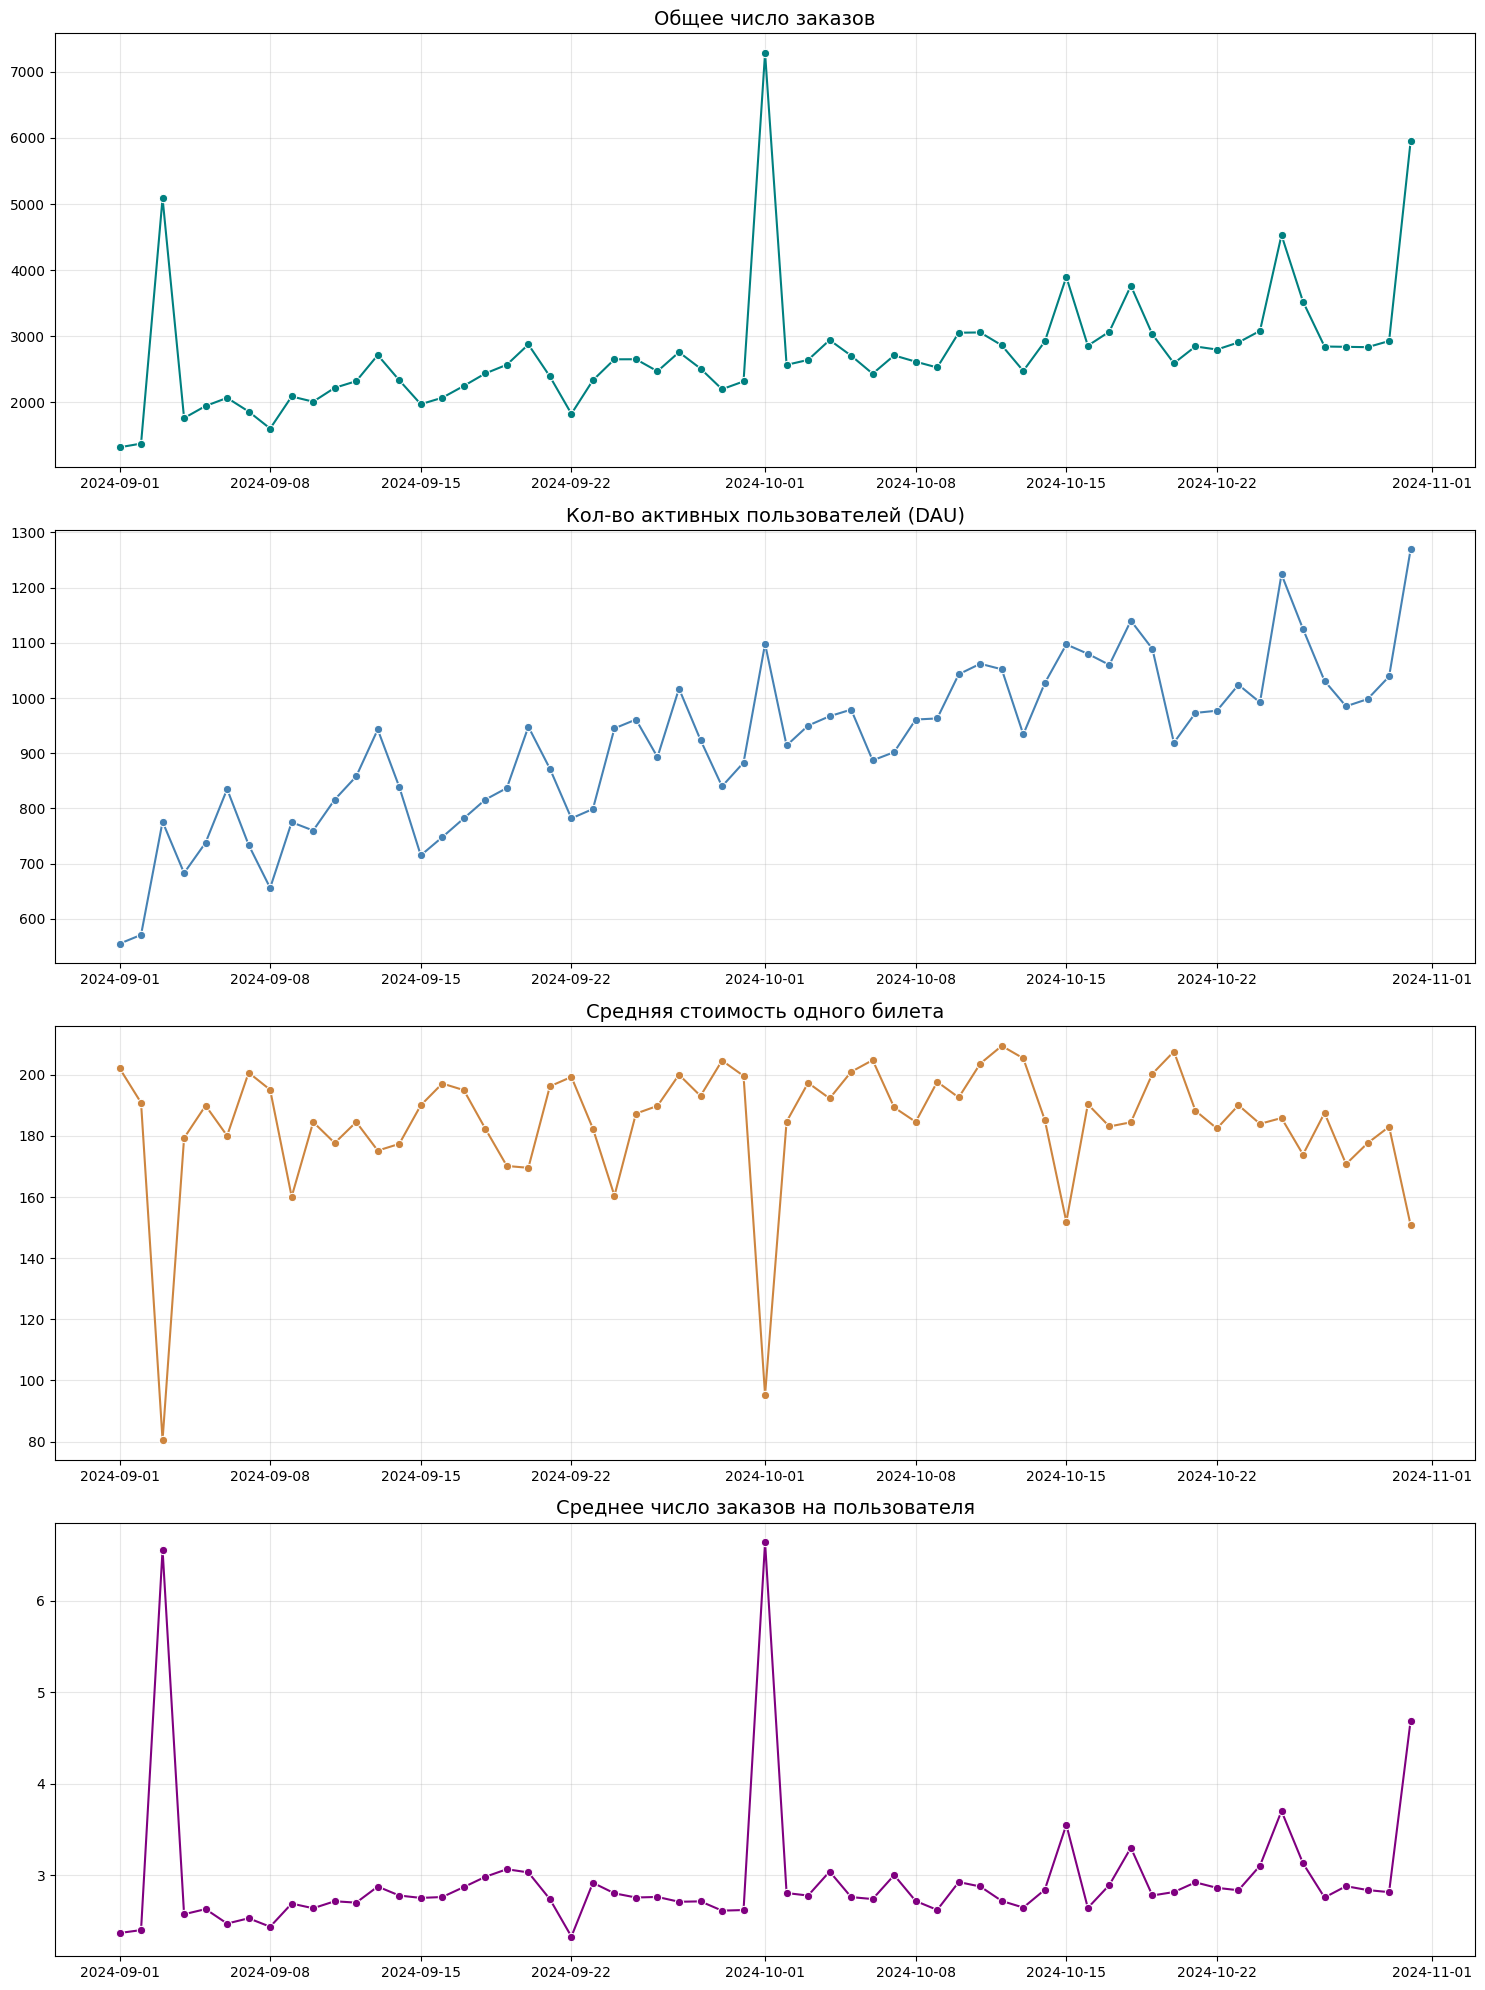

In [25]:
# Визуализируем таблицу
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

metrics = [
    ('orders_count', 'Общее число заказов', 'teal'),
    ('dau', 'Кол-во активных пользователей (DAU)', 'steelblue'),
    ('avg_ticket_price', 'Средняя стоимость одного билета', 'peru'),
    ('orders_per_user', 'Среднее число заказов на пользователя', 'purple')
]

for i, (col, title, color) in enumerate(metrics):
    sns.lineplot(
        data = daily_stats,
        x = 'created_dt_msk',
        y = col,
        ax = axes[i],
        color = color,
        marker = 'o'
    )
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

1. Общее число заказов:

Наблюдается умеренный восходящий тренд с явной цикличной активностью (вероятно, недельной). Есть два резких пика — в начале сентября (примерно 5000 заказов) и около 1го октября (свыше 7000 заказов). В конце октября также заметен резкий рост до 6000 заказов.

2. Кол-во активных пользователей (DAU):

Стабильный рост аудитории с начала сентября (600-800 активных пользователей) к концу октября (1000-1300). Форма графика с постоянно чередующимися и не резкими подъемами и спадами, может характеризоваться разницой в активности между буднями и выходными.

3. Средняя стоимость одного билета:

Показатели на графике можно назвать стабильными. Средняя стоимость билета находится в диапазоне от 160 до 220 рублей. Имеются резкие спады цены в 3го сентября и 1го октября. Возможно, в этот моменд действовала распродажа.

4. Среднее число заказов на пользователя:

Показатели на графике можно назвать стабильными. Среднее число заказов на пользователя находится в диапазоне 2-3 билетов. Два резких пика зеркально совпадают со снижением цены из предыдущего графика. В случае проведения акции/распродажи резкое увеличение покупаемых билетов на пользователя закономерно. 

In [26]:
# Выделим дни недели
df_autumn['day_num'] = df_autumn['created_dt_msk'].dt.dayofweek

# Создадим столбец обозначающий будни / выходные
df_autumn['is_weekend'] = df_autumn['day_num'].isin([5, 6]).map({True: 'Выходной', False: 'Будний'})

display(df_autumn)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season,day_num,is_weekend
0,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0+,rub,mobile,1258.57,...,213.0,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.569946,314.642487,10,осень,6,Выходной
1,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18+,rub,mobile,1390.41,...,240.0,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.410034,463.470001,10,осень,4,Будний
2,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12+,rub,mobile,902.74,...,193.0,930,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",902.739990,300.913330,10,осень,2,Будний
3,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12+,rub,mobile,47.78,...,18.0,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",47.779999,47.779999,9,осень,6,Выходной
4,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12+,rub,mobile,74.84,...,18.0,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",74.839996,37.419998,10,осень,1,Будний
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167839,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6+,rub,mobile,965.57,...,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",965.570007,241.392502,10,осень,6,Выходной
167840,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6+,rub,mobile,1448.36,...,213.0,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",1448.359985,241.393326,10,осень,6,Выходной
167841,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16+,rub,desktop,178.95,...,213.0,3470,"Клуб киноманов ""Верность"" Лтд","пр. Титова, д. 5 стр. 68",178.949997,89.474998,10,осень,2,Будний
167842,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18+,rub,desktop,661.53,...,239.0,2449,"Гильдия художников ""Флит"" Инк","пр. Макарова, д. 4",661.530029,330.765015,9,осень,1,Будний


<a class='anchor' id="link3"></a>

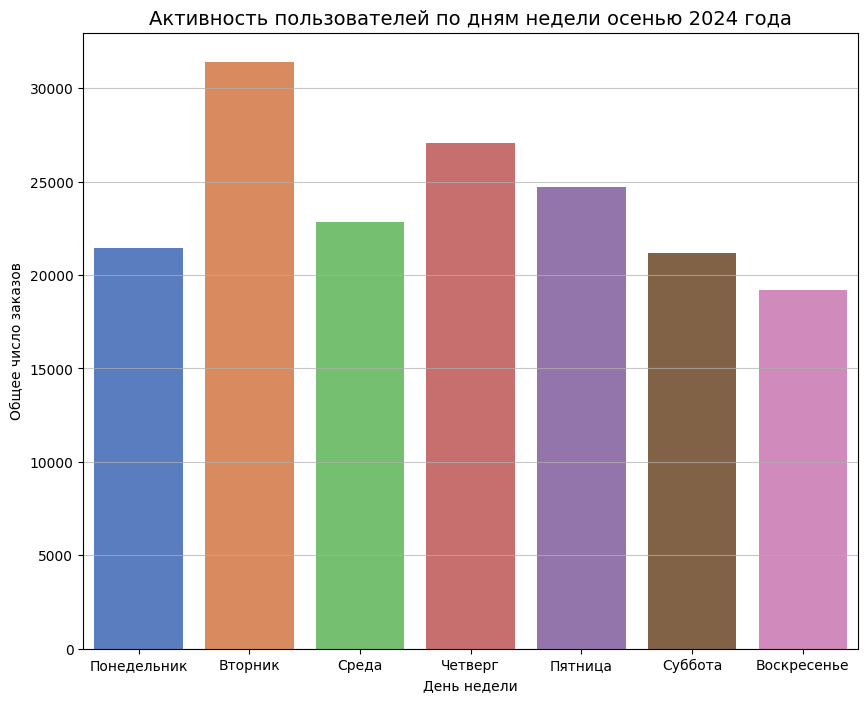

In [27]:
# Визуализируем недельную цикличность
week_activity = df_autumn.groupby('day_num')['order_id'].count().reset_index()
day_names = {
     0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'
}
ticks = sorted(week_activity['day_num'].unique())
labels = [day_names.get(d, d) for d in ticks]

plt.figure(figsize=(10,8))

sns.barplot(
        data = week_activity,
        x = 'day_num',
        y ='order_id',
        palette = 'muted',
        hue = 'day_num',
        legend = False
)

plt.title('Активность пользователей по дням недели осенью 2024 года', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Общее число заказов')
plt.grid(axis='y', alpha=0.7)
plt.xticks(week_activity['day_num'].unique())
plt.xticks(ticks, labels)

plt.show()

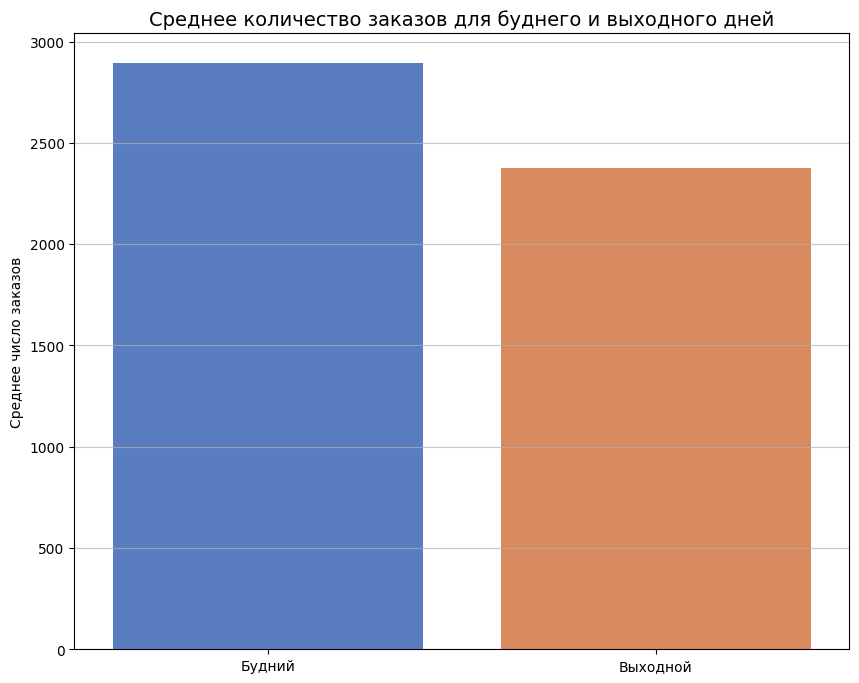

In [28]:
# Сравним среднее кол-во заказов в будний и выходной дни
daily_totals = df_autumn.groupby(['created_dt_msk', 'is_weekend'])['order_id'].count().reset_index()
weekend_stats = daily_totals.groupby('is_weekend')['order_id'].mean().reset_index()

plt.figure(figsize=(10,8))

sns.barplot(
        data = weekend_stats,
        x = 'is_weekend',
        y ='order_id',
        palette = 'muted',
        hue = 'is_weekend',
        legend = False
)

plt.title('Среднее количество заказов для буднего и выходного дней', fontsize=14)
plt.xlabel('')
plt.ylabel('Среднее число заказов')
plt.grid(axis='y', alpha=0.7)

plt.show()

**Промежуточные выводы по графикам:**

**Недельная цикличность:** Пик покупательской активности зафиксирован во вторник и четверг. Самая низкая активность: воскресенье, суббота и понедельник. Вероятно, пользователи предпочитают планировать свой досуг заранее и покупают билеты в течение рабочей недели.

**Сравнение активности в будние и выходные дни:** Средняя активность в будние дни выше, чем в выходные. Среднее количество заказов в будни составляет около 2900 против примерно 2400 в выходные. Это может быть связано с тем, что в выходные люди уже посещают мероприятия, а не покупают билеты на них.

<a class="anchor" id="3.3-bullet" ></a>
### 3.3. Популярные события и партнёры

In [29]:
# Считаем статистику регионов и находим то по разнообразию мероприятий
regions_stat = df_autumn.groupby('region_name').agg(
                uniq_events_count = ('event_id', 'nunique'),
                total_orders = ('order_id', 'count')
).reset_index()

regions_stat['event_share_pct'] = ((regions_stat['uniq_events_count'] / regions_stat['uniq_events_count'].sum()) * 100).round(2)
regions_stat['order_share_pct'] = ((regions_stat['total_orders'] / regions_stat['total_orders'].sum()) * 100).round(2)

top_regions = regions_stat.sort_values(by='uniq_events_count', ascending=False).reset_index(drop = True)

display(top_regions)

,region_name,uniq_events_count,total_orders,event_share_pct,order_share_pct
0,Каменевский регион,3893,46574,24.68,27.75
1,Североярская область,2597,20626,16.46,12.29
2,Широковская область,794,8645,5.03,5.15
3,Светополянский округ,755,4751,4.79,2.83
4,Речиновская область,529,3565,3.35,2.12
...,...,...,...,...,...
74,Залесский край,4,56,0.03,0.03
75,Островогорский округ,4,18,0.03,0.01
76,Верхозёрский край,2,11,0.01,0.01
77,Светолесский край,2,18,0.01,0.01


In [30]:
# Считаем статистику билетных партнёров
partners_stat = df_autumn.groupby('service_name').agg(
                uniq_events_count = ('event_id', 'nunique'),
                total_orders = ('order_id', 'count'),
                total_revenue = ('revenue_rub', 'sum')
).reset_index()

partners_stat['event_share_pct'] = ((partners_stat['uniq_events_count'] / partners_stat['uniq_events_count'].sum()) * 100).round(2)
partners_stat['order_share_pct'] = ((partners_stat['total_orders'] / partners_stat['total_orders'].sum()) * 100).round(2)
partners_stat['revenue_share_pct'] = ((partners_stat['total_revenue'] / partners_stat['total_revenue'].sum()) * 100).round(2)

top_partners = partners_stat.sort_values(by='total_revenue', ascending=False).reset_index(drop = True)

display(top_partners)

,service_name,uniq_events_count,total_orders,total_revenue,event_share_pct,order_share_pct,revenue_share_pct
0,Билеты без проблем,2821,32005,1.211604e+07,16.40,19.07,14.82
1,Мой билет,1005,19416,1.085068e+07,5.84,11.57,13.27
2,Облачко,1409,15478,1.061105e+07,8.19,9.22,12.98
3,Лови билет!,3584,25707,1.037682e+07,20.84,15.32,12.69
4,Весь в билетах,599,9405,9.324686e+06,3.48,5.60,11.40
5,Билеты в руки,2445,25536,7.613198e+06,14.22,15.21,9.31
6,Край билетов,193,2997,3.018372e+06,1.12,1.79,3.69
7,Яблоко,537,3473,2.763332e+06,3.12,2.07,3.38
8,Прачечная,728,5798,2.548310e+06,4.23,3.45,3.12
9,Тебе билет!,858,3748,2.137906e+06,4.99,2.23,2.61


<a class='anchor' id="link4"></a>

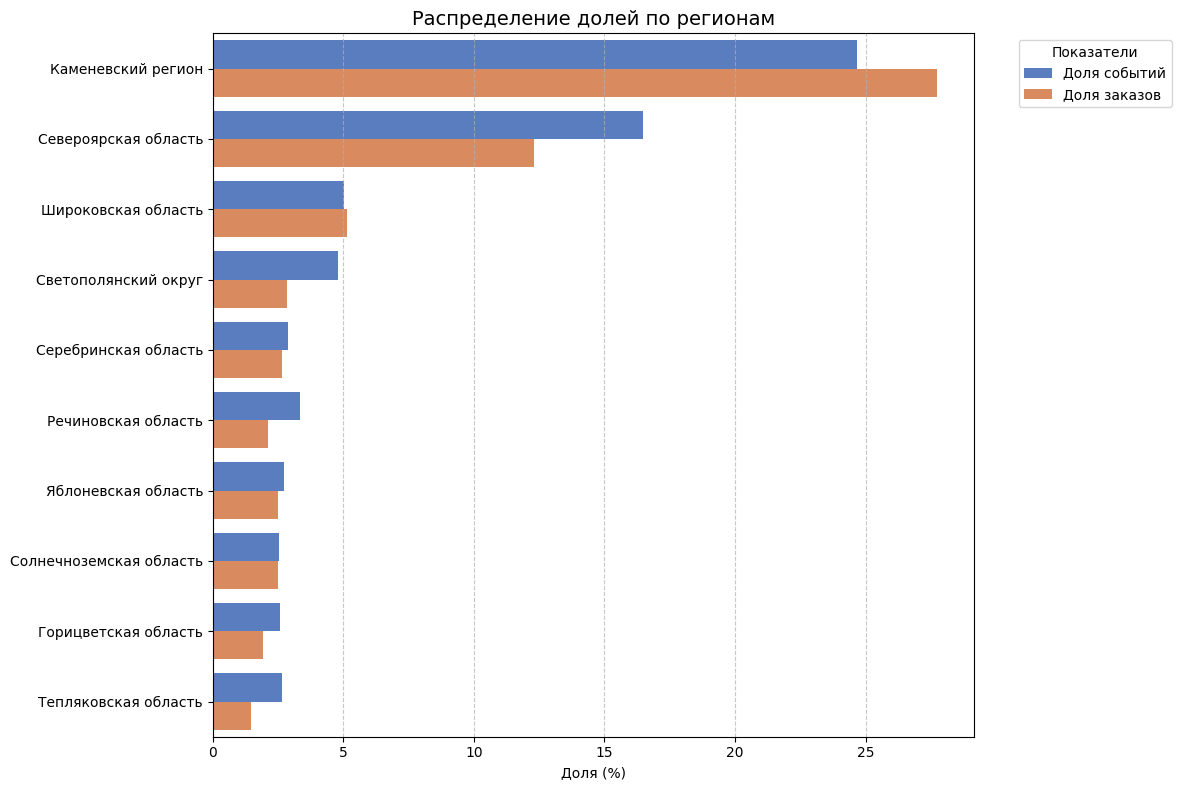

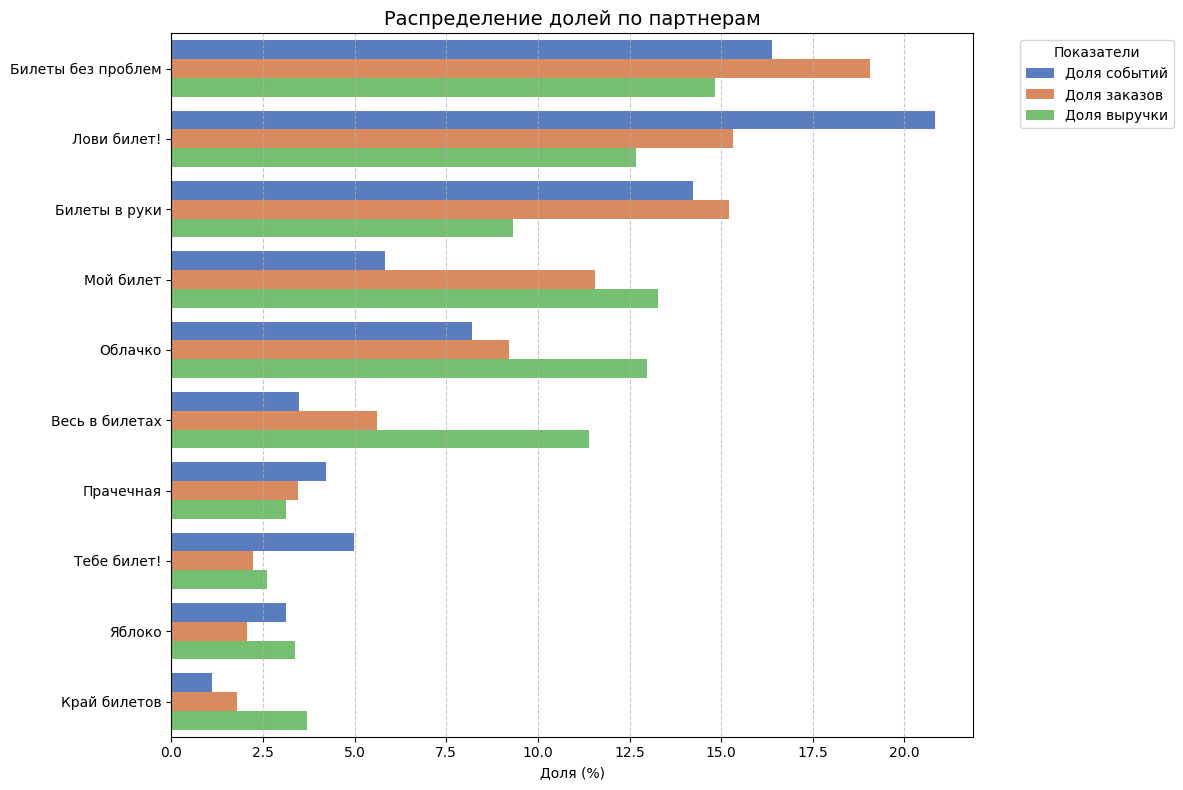

In [31]:
# Создадим функцию, строющею график по долям
def plot_shares(df, title):
    share_cols = [c for c in df.columns if 'share_pct' in c]
    group_col = df.columns[0]
    
    names_map = {
        'event_share_pct': 'Доля событий',
        'order_share_pct': 'Доля заказов',
        'revenue_share_pct': 'Доля выручки'
    }
    
    df_sorted = df.assign(total_sum = df[share_cols].sum(axis=1)) \
                  .sort_values('total_sum', ascending=False) \
                  .drop(columns='total_sum')

    df_melted = df_sorted.melt(id_vars=[group_col], value_vars=share_cols, 
                               var_name='Показатель', value_name='Процент')
    
    df_melted['Показатель'] = df_melted['Показатель'].map(names_map)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data = df_melted, 
        y = group_col, 
        x = 'Процент', 
        hue = 'Показатель', 
        palette = 'muted'
    )
    
    plt.title(title, fontsize=14)
    plt.xlabel('Доля (%)')
    plt.ylabel('')
    plt.legend(title='Показатели', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
plot_shares(top_regions.head(10), "Распределение долей по регионам")
plot_shares(top_partners.head(10), "Распределение долей по партнерам")

**Промежуточные выводы по графикам:**

**Распределение долей по регионам.** Из 79 регионов был выведен топ-10, в котором есть явные лидеры: Каменевский регион и Североярская область. На них приходится около 40% мероприятий и заказов билетов. Далее следует резкий спад и остальные имеют низкие и примерно равные доли до 2-5%. Из этого следует, что основное разнообразие мероприятий и количество продаж сосредоточены в двух ключевых регионах.

**Распределение долей по партнерам.** Из 35 партнеров был выведен топ-10, в котором:
- Есть лидеры: 'Билеты без проблем', 'Лови билет!', 'Билеты в руки'. Показатели в диапазоне 12-20%;
- Средняя группа: 'Мой билет', 'Облачко', 'Весь в билетах'. Показатели в диапазоне 5-12%;
- Группа с низкими показателями: 'Прачечная', 'Тебе билет!', 'Яблоко', 'Край билетов'. Показатели менее 5%.

Таким образом, среди партнеров наблюдается более плавное распределение показателей, чем у регионов. Однако есть некоторый дисбаланс метрик у отдельновзятых билетных операторов. Например:
- 'Лови билет!'. Лидер по доле событий уступает по доле выручки партнеру 'Билеты без проблем'.
- 'Весь в билетах'. Имеет высокую долю выручки при небольших долях заказов и событий.

Это может указывать на разную конверсию или разный средний чек у партнеров.

<a class="anchor" id="4-bullet" ></a>
## 4. Статистический анализ данных

**Сформулируем гипотезы.**

**Гипотеза №1:**

Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

**Нулевая гипотеза (H0)**: Среднее количество заказов у пользователей мобильных устройств не больше, чем у стационарных. $\mu_{mobile} \le \mu_{desktop}$

**Альтернативная гипотеза (H1)**: Среднее количество заказов у пользователей мобильных приложений выше, чем у стационарных. $\mu_{mobile} > \mu_{desktop}$

**Гипотеза №2:**

Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

**Нулевая гипотеза (H0)**: Среднее время между заказами у пользователей мобильных устройств не больше, чем у стационарных. $\mu_{mobile} \le \mu_{desktop}$

**Альтернативная гипотеза (H1)**: Среднее время между заказами у пользователей мобильных приложений выше, чем у стационарных. $\mu_{mobile} > \mu_{desktop}$

<a class="anchor" id="4.1-bullet" ></a>
### 4.1 Подготовка выборок для теста

In [32]:
# Приведем столбец days_since_prev к типу данных float
df_autumn['days_since_prev'] = df_autumn['days_since_prev'].astype(float)

# Для гипотезы 1 выделим группы с количеством заказов на пользователя в разрезе устройств
mobile_orders = df_autumn.query("device_type_canonical == 'mobile'").groupby('user_id')['order_id'].count()
desktop_orders = df_autumn.query("device_type_canonical == 'desktop'").groupby('user_id')['order_id'].count()

# Для гипотезы 2 выделим группы со среднем временем между заказами на пользователя в разрезе устройств
df_intervals = df_autumn.dropna(subset=['days_since_prev'])

orders_intervals_mobile = df_intervals.query("device_type_canonical == 'mobile'").groupby('user_id')['days_since_prev'].mean()
orders_intervals_desktop = df_intervals.query("device_type_canonical == 'desktop'").groupby('user_id')['days_since_prev'].mean()

<a class="anchor" id="4.2-bullet" ></a>
### 4.2 Сравнение размеров групп и их статистик

In [33]:
h1_stats = pd.DataFrame({
    'mobile': mobile_orders.describe(percentiles=[0.25, 0.5, 0.75, 0.99]),
    'desktop': desktop_orders.describe(percentiles=[0.25, 0.5, 0.75, 0.99])
}).T

h2_stats = pd.DataFrame({
    'mobile': orders_intervals_mobile.describe(percentiles=[0.25, 0.5, 0.75, 0.99]),
    'desktop': orders_intervals_desktop.describe(percentiles=[0.25, 0.5, 0.75, 0.99])
}).T

print('Сравнение заказов в разрезе устройств (Гипотеза №1):')
display(h1_stats)

print('Интервалы между заказами в разрезе устройств (Гипотеза №2):')
display(h2_stats)

Сравнение заказов в разрезе устройств (Гипотеза №1):


,count,mean,std,min,25%,50%,75%,99%,max
mobile,14106.0,9.471785,67.943135,1.0,1.0,2.0,5.0,115.00,4312.0
desktop,4862.0,7.041341,35.905247,1.0,1.0,2.0,4.0,102.78,1494.0


Интервалы между заказами в разрезе устройств (Гипотеза №2):


,count,mean,std,min,25%,50%,75%,99%,max
mobile,10151.0,20.559188,27.320189,0.0,2.039231,9.5,27.666667,122.0,148.0
desktop,4029.0,14.868323,24.209941,0.0,1.000000,4.5,17.000000,116.0,146.0


**Промежуточные выводы по статистикам:**

**Гипотеза №1. Сравнение количества заказов на пользователя в разрезе устройств:** 
1. Разница в количестве. Заказов с мобильных устройств примерно в 3 раза больше, чем со стационарных;
2. Среднее количество заказов у пользователей мобильных устройств выше, чем у стационарных, а медианное не отличается;
3. Распределение. Среднее > медианы для обоих типов устройств, это говорит о правосторонней асимметрии. Большая часть пользователей совершает 1-2 заказа.

**Гипотеза №2. Интервалы между заказами пользователей в разрезе устройств:** 
1. Средний интервал времени между заказами у мобильных пользователей составляет примерно 20.6 дней, тогда как у стационарных — около 15 дней. Эти показатели подтверждают предположение, что время между заказами у 'мобильных' пользователей выше;
2. Распределение. Среднее > медианы для обоих типов устройств, это говорит о правосторонней асимметрии.

<a class="anchor" id="4.3-bullet" ></a>
### 4.3 Проведение теста

**Выбор статистического теста.**

Для проверки гипотез выбран `t-тест Уэлча`. Выбор обусловлен несколькими факторами:

1. Разный размер выборок;
2. Разброс значений в группах.

In [34]:
# Убедимся, что данных в выборках достаточно для теста
alpha = 0.05
power = 0.8 
effect_size = 0.2 

power_analysis = TTestIndPower()

ratio_h1 = len(mobile_orders) / len(desktop_orders)
ratio_h2 = len(orders_intervals_mobile) / len(orders_intervals_desktop)

sample_size_h1 = power_analysis.solve_power(effect_size=effect_size,
                                      alpha=alpha,
                                      power=power,
                                      ratio=ratio_h1
)
sample_size_h2 = power_analysis.solve_power(effect_size=effect_size,
                                      alpha=alpha,
                                      power=power,
                                      ratio=ratio_h1
)

print(f'Минимальный размер выборки для проверки Гипотезы №1: {int(sample_size_h1)} пользователей.')
print(f"""Фактические размеры выборкок для проверки Гипотезы №1. 
Мобильные устройства: {len(mobile_orders)} пользователей;
Стационарные устройства: {len(desktop_orders)} пользователей.""")

print(f'\nМинимальный размер выборки для проверки Гипотезы №2: {int(sample_size_h2)} пользователей.')
print(f"""Фактические размеры выборкок для проверки Гипотезы №2. 
Мобильные устройства: {len(orders_intervals_mobile)} пользователей;
Стационарные устройства: {len(orders_intervals_desktop)} пользователей.""")

Минимальный размер выборки для проверки Гипотезы №1: 264 пользователей.
Фактические размеры выборкок для проверки Гипотезы №1. 
Мобильные устройства: 14106 пользователей;
Стационарные устройства: 4862 пользователей.

Минимальный размер выборки для проверки Гипотезы №2: 264 пользователей.
Фактические размеры выборкок для проверки Гипотезы №2. 
Мобильные устройства: 10151 пользователей;
Стационарные устройства: 4029 пользователей.


In [35]:
alpha = 0.05

# Проведем t-тест Уэлча для Гипотезы №1
stat_welch_ttest1, p_value_welch_ttest1 = ttest_ind(
        mobile_orders,
        desktop_orders,
        equal_var=False,
        alternative='greater'
)

# Проведем t-тест Уэлча для Гипотезы №2
stat_welch_ttest2, p_value_welch_ttest2 = ttest_ind(
        orders_intervals_mobile,
        orders_intervals_desktop,
        equal_var=False,
        alternative='greater'
)

if p_value_welch_ttest1 > alpha:
    print(f'p-value теста Уэлча для Гипотезы №1 = {p_value_welch_ttest1}')
    print('Нулевая гипотеза находит подтверждение! Среднее количество заказов у пользователей мобильных устройств не выше, чем у стационарных.')
else:
    print(f'p-value теста Уэлча для Гипотезы №1 = {p_value_welch_ttest1}')
    print('Нулевая гипотеза не находит подтверждения! Среднее количество заказов у пользователей мобильных приложений значимо выше, чем у стационарных.')
    
if p_value_welch_ttest2 > alpha:
    print(f'\np-value теста Уэлча для Гипотезы №2 = {p_value_welch_ttest2}')
    print('Нулевая гипотеза находит подтверждение! Среднее время между заказами у пользователей мобильных устройств не выше, чем у стационарных.')
else:
    print(f'\np-value теста Уэлча для Гипотезы №2 = {p_value_welch_ttest2}')
    print('Нулевая гипотеза не находит подтверждения! Среднее время между заказами у пользователей мобильных приложений значимо выше, чем у стационарных.')

p-value теста Уэлча для Гипотезы №1 = 0.0007965200932566095
Нулевая гипотеза не находит подтверждения! Среднее количество заказов у пользователей мобильных приложений значимо выше, чем у стационарных.

p-value теста Уэлча для Гипотезы №2 = 4.883243283972082e-34
Нулевая гипотеза не находит подтверждения! Среднее время между заказами у пользователей мобильных приложений значимо выше, чем у стационарных.


**Промежуточные выводы по тестам:**

В **Гипотезе №1** предполагалось, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

По результатам теста: pvalue = 0.0 < 0.05, отвергаем нулевую гипотезу. Результат подтвердил, что пользователи мобильных приложений заказывают значимо чаще, чем пользователи стационарных устройств (в среднем 9.5 заказов против 7).

В **Гипотезе №2** предполагалось, что среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

По результатам теста: pvalue=0.0 < 0.05, можно с уверенностью отвергнуть нулевую гипотезу. Результат показал, что среднее время между заказами у пользователей мобильных приложений значимо выше, чем у стационарных. Согласно ранее рассчитанным статистикам среднее время 'мобильных' заказов выше, чем у 'стационарных' (в среднем 20.6 дней против 15).

<a class="anchor" id="5-bullet" ></a>
## 5. Общий вывод и рекомендации

**Информация о данных**

Для анализа использовались данные датасетов:
- `final_tickets_orders_df.csv`, содержащего информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных;
- `final_tickets_events_df.csv`, содержащего информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля;
- `final_tickets_tenge_df.csv`, содержащего информацию о курсе тенге к российскому рублю за 2024 год.

**Основные результаты анализа**

*Востребованные мероприятия.* Концерты, театры и другое (выставки, спектакли, экскурсии, шоу) являются топ-3 категориями как для летнего, так и для осеннего сезонов. Осенью заметно выросла доля театров и спортивных событий, а доля концертов снизилась. Это может быть связано с началом театрального сезона. [Смотреть график](#link1)

*Средняя цена билета.* Анализ показал, что у большинства типов мероприятий средняя цена билета в осенний период относительно летнего снижается. Исключениями являются мероприятия типа выставки и стендап, где цена за билет возрастает почти на 6%.

Среднее снижение цены билета осенью составляет -8.1%. [Смотреть график](#link2)

*Пользовательская активность.* Осенью наблюдается рост общего количества заказов. Наблюдается недельная цикличность: Пик покупательской активности зафиксирован во вторник и четверг. Самая низкая активность: воскресенье, суббота и понедельник. [Смотреть график](#link3)

*Регионы.* Распределение между регионами неравномерное. Есть явные лидеры: Каменевский регион и Североярская область. На них приходится около 40% мероприятий и заказов билетов.

*Партнеры.* Среди билетных операторов более диверсифицированное распределение. Выделяются 3–5 лидеров, на которых приходятся основные доли выручки и мероприятий, однако переход от лидеров к аутсайдерам более плавный, чем у регионов.

[Смотреть графики распределения по регионам и партнерам](#link4)

**Результаты проверки гипотез**

*Гипотеза №1 (Подтверждена):* Среднее количество заказов в мобильном приложении статистически значимо выше, чем на стационарных устройствах.

*Гипотеза №2 (Подтверждена):* Предположение о том, что время между заказами в в мобильном приложении выше, подтвердилось. Мобильные пользователи возвращаются за покупками медленнее (9.5 дней против 14.5 по медиане).

**Рекомендации:**

1. Разрыв между регионами. С учетом большого разрыва между двумя регионами-лидерами и остальными, стоит рассмотреть локальные промо-компании в крупных городах, с низкими показателями количества мероприятий.

2. Среди партнеров есть битлетные операторы с дисбалансом метрик. Больше других выделяется партнер 'Лови билет!', имеющий высокую долю уникальных событий и существенно низже доли заказов и выручки. Возможно стоит пересмотреть условия сотрудничества.

3. Приоритезация мобильных пользователей. Основной трафик приходит через мобильное приложение,однако возвращение пользователей происходит медленнее. Внедрение персонализированных подборок, отправка пуш-уведомлений.

4. Недельная динамика. Анализ показал наибольшую активность при покупке билетов во вторник и четверг. Таким образом, уведомления о новинках и акциях наиболее эффективно рассылать утром в эти же дни или вечером накануне.